# Logan database benchmark: metadata versus no_metadata

This notebook executes repeated benchmarks against the databases built in notebook 01. Shared workloads return identical results in both variants. Thirty measured repetitions follow five warm-up repetitions. Reported metrics include median, mean, standard deviation, minimum, maximum, p95 latency, workloads per second, logical operations per second, database pages, file size, query plans, SQLite integrity, and fresh-subprocess baseline and peak RSS.

The accession filter compares indexed normalized metadata with an equivalent identifier-prefix query. Scientific-name, library-source, and abundance analyses are metadata-only capabilities and are reported separately rather than assigned fabricated values for `no_metadata`.

In [1]:
from IPython.display import Image, display
from benchmark_core import (
    benchmark_environment,
    benchmark_variants,
    create_figures,
    memory_benchmark,
    metadata_capabilities,
    project_root,
    storage_and_plans,
)

ROOT = project_root()
display(benchmark_environment().T)

,0
timestamp_utc,2026-09-08T03:11:50.660089+00:00
python,3.11.14
sqlite,3.51.1
platform,Linux-6.18.49-x86_64-with-glibc2.40
cpu_logical,4
cpu_physical,4
memory_gib,7.778587
logan_revision,b3da25311802544c4c0e53c44b98380acf4d04d6
logan_analysis_revision,5e92dafb87e40834ff2123d9b55e3bb27887fedb
petadex_revision,a6bc326eb187925591b3988f57b4fadb1dba557d


In [2]:
raw, query_summary, result_proof = benchmark_variants(ROOT, repetitions=30, warmups=5)
display(query_summary.sort_values(['query', 'variant']))

,variant,query,median_ms,mean_ms,stddev_ms,minimum_ms,maximum_ms,p95_ms,workloads_per_second,logical_operations_per_second
0,metadata,accession_filter,1.319452,1.389105,0.370947,1.288270,3.347322,1.432924,757.890397,757.890397
7,no_metadata,accession_filter,2.048624,2.068170,0.053295,2.004181,2.218458,2.196190,488.132522,488.132522
1,metadata,average_length,15.014302,15.337118,0.693607,14.724732,17.146184,17.073666,66.603165,66.603165
8,no_metadata,average_length,14.839275,14.935319,0.458020,14.033631,16.169984,16.164480,67.388735,67.388735
2,metadata,count_all,0.031176,0.032113,0.003699,0.030313,0.050650,0.036838,32075.955863,32075.955863
9,no_metadata,count_all,0.029652,0.031337,0.005924,0.028984,0.056905,0.048299,33724.537974,33724.537974
3,metadata,gc_range_count,4.558031,4.556811,0.024044,4.509898,4.621843,4.587587,219.392979,219.392979
10,no_metadata,gc_range_count,4.612297,4.659436,0.174151,4.348134,5.355156,5.060269,216.811710,216.811710
4,metadata,indexed_lookup_batch_200,1.629219,1.635329,0.043047,1.561893,1.739464,1.719450,613.791025,122758.205005
11,no_metadata,indexed_lookup_batch_200,1.775414,1.863754,0.382442,1.674027,3.809406,2.215973,563.248910,112649.781966


In [3]:
storage, plans = storage_and_plans(ROOT)
display(storage)
plans

,variant,database_mib,page_count,page_size,sequence_count,metadata_rows,integrity_check
0,no_metadata,33.480469,8571,4096,113113,0,ok
1,metadata,43.671875,11180,4096,113113,6,ok


{'no_metadata': {'count_all': [(4,
    0,
    0,
    'SCAN sequences USING COVERING INDEX idx_sequences_gc')],
  'length_range_count': [(3,
    0,
    153,
    'SEARCH sequences USING COVERING INDEX idx_sequences_length (length>? AND length<?)')],
  'average_length': [(3,
    0,
    213,
    'SCAN sequences USING COVERING INDEX idx_sequences_length')],
  'gc_range_count': [(3,
    0,
    153,
    'SEARCH sequences USING COVERING INDEX idx_sequences_gc (gc_fraction>? AND gc_fraction<?)')],
  'top_100_longest': [(4,
    0,
    213,
    'SCAN sequences USING COVERING INDEX idx_sequences_length')],
  'indexed_lookup_batch_200': [(2,
    0,
    39,
    'SEARCH sequences USING PRIMARY KEY (sequence_id=?)')],
  'accession_filter': [(3,
    0,
    155,
    'SEARCH sequences USING PRIMARY KEY (sequence_id>? AND sequence_id<?)')]},
 'metadata': {'count_all': [(4,
    0,
    0,
    'SCAN sequences USING COVERING INDEX idx_sequences_gc')],
  'length_range_count': [(3,
    0,
    151,
    'SEARCH s

In [4]:
memory = memory_benchmark(ROOT)
display(memory)

,baseline_rss_mib,peak_rss_mib,rss_delta_mib,workload_seconds,variant,repetition
0,15.148438,46.644531,31.496094,0.744755,no_metadata,1
1,15.171875,50.593750,35.421875,1.870089,metadata,1
2,15.050781,50.414062,35.363281,1.846498,metadata,2
3,15.054688,46.570312,31.515625,0.722190,no_metadata,2
4,15.148438,46.691406,31.542969,0.732548,no_metadata,3
5,15.164062,50.578125,35.414062,1.742422,metadata,3
6,15.117188,50.546875,35.429688,1.788179,metadata,4
7,15.121094,46.695312,31.574219,0.736251,no_metadata,4
8,15.050781,46.566406,31.515625,0.736821,no_metadata,5
9,15.257812,50.582031,35.324219,1.741171,metadata,5


In [5]:
capabilities = metadata_capabilities(ROOT)
display(capabilities)

,capability,median_ms,p95_ms,minimum_ms,maximum_ms,repetitions,result_rows,result_sha256,result
0,sequences_by_library_source,36.390125,41.145756,35.292953,52.557354,30,2,05298950f01e59a71d490af5c7d868a7aee4e95a93fb6a...,"[[""TRANSCRIPTOMIC"", 109668], [""GENOMIC"", 3445]]"
1,sequences_by_run_scientific_name,37.625348,47.584883,35.953552,55.604674,30,6,a26c499ea6477574d0259e9501eb64681924fbb47b304a...,"[[""Mus musculus"", 53453], [""Pinctada fucata"", ..."
2,high_abundance_sequences_by_run_scientific_name,120.010096,129.957809,115.315928,130.624531,30,6,45403f46b1d31a71fc1c7a89e445be0c9206726b32c6ce...,"[[""Mus musculus"", 31781], [""Canis lupus famili..."


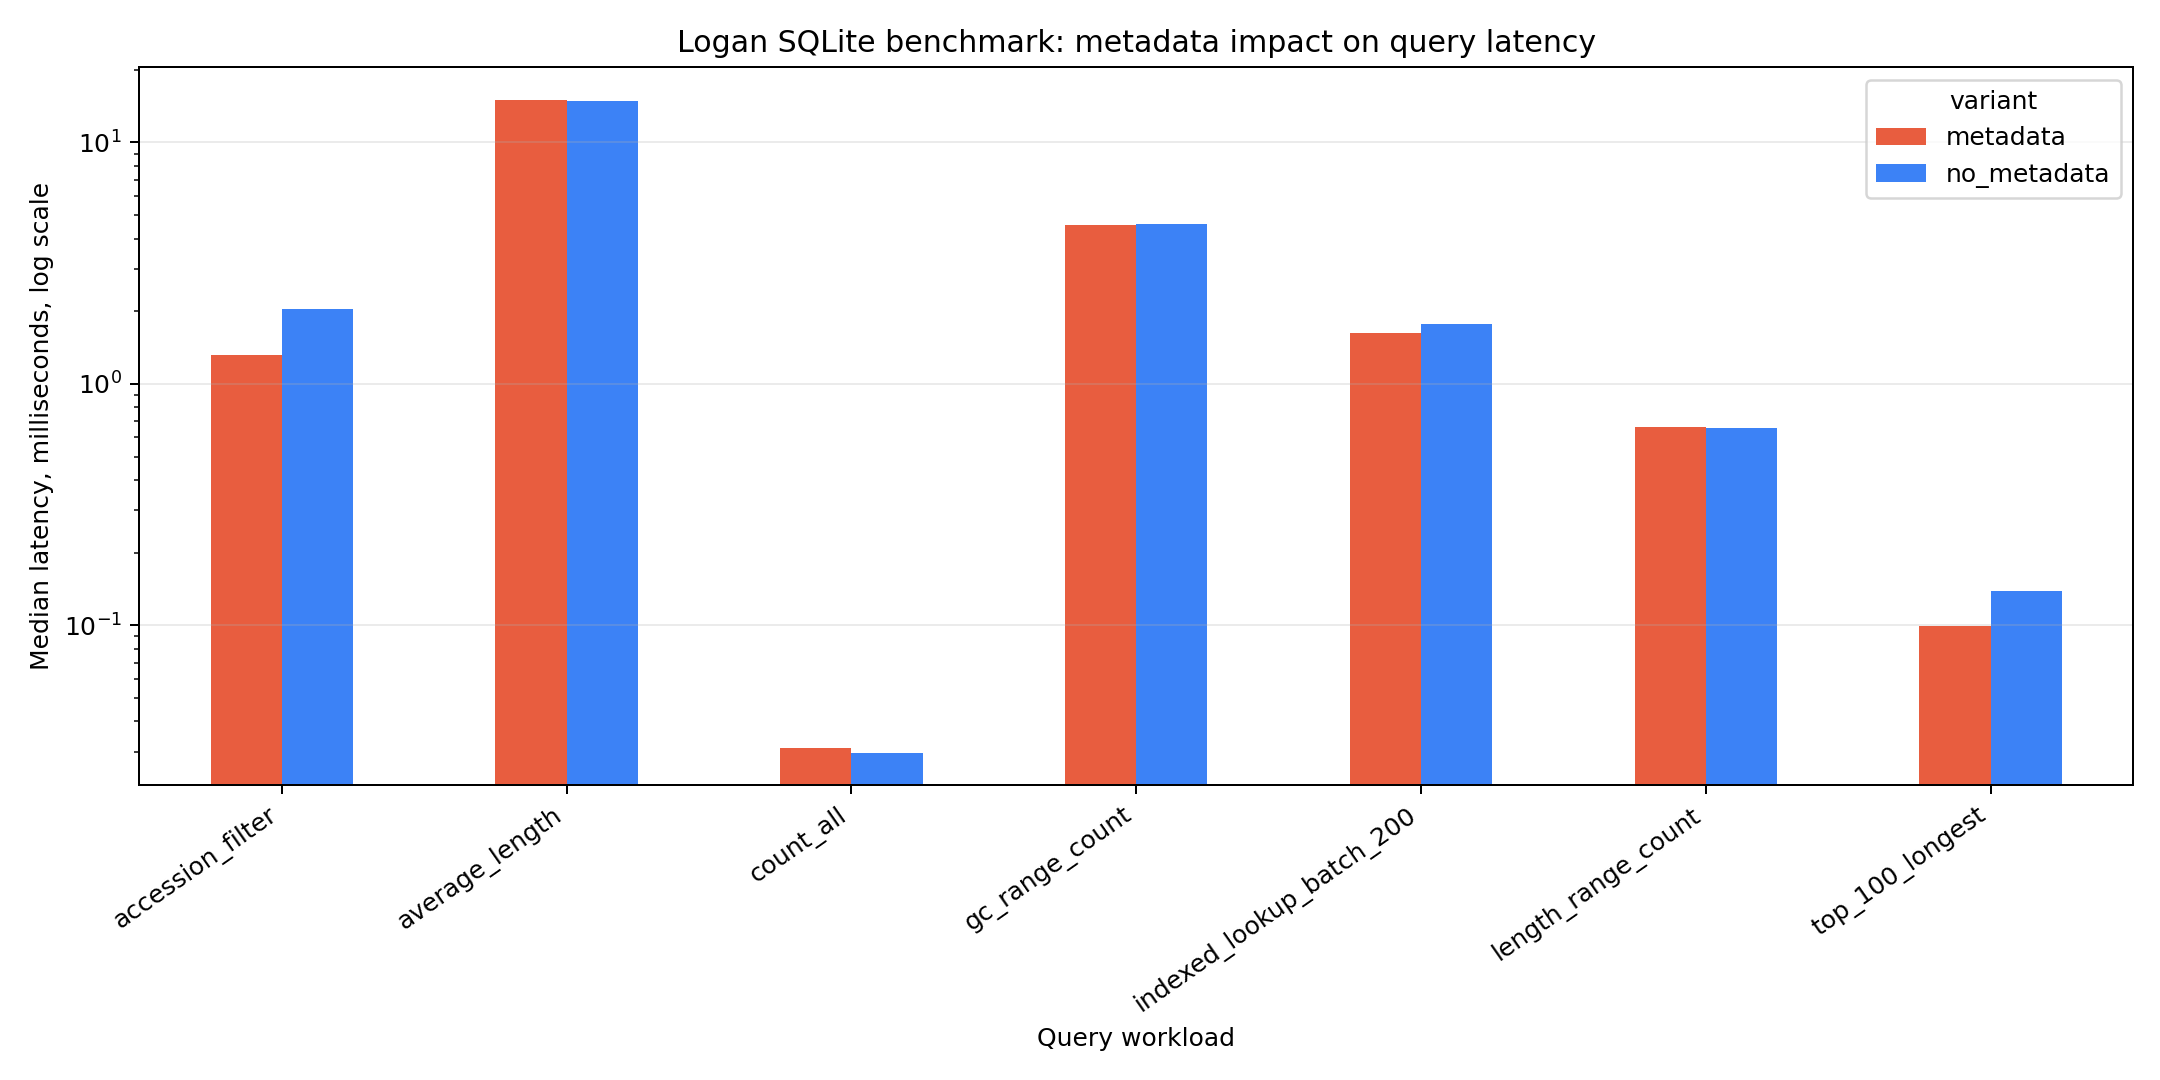

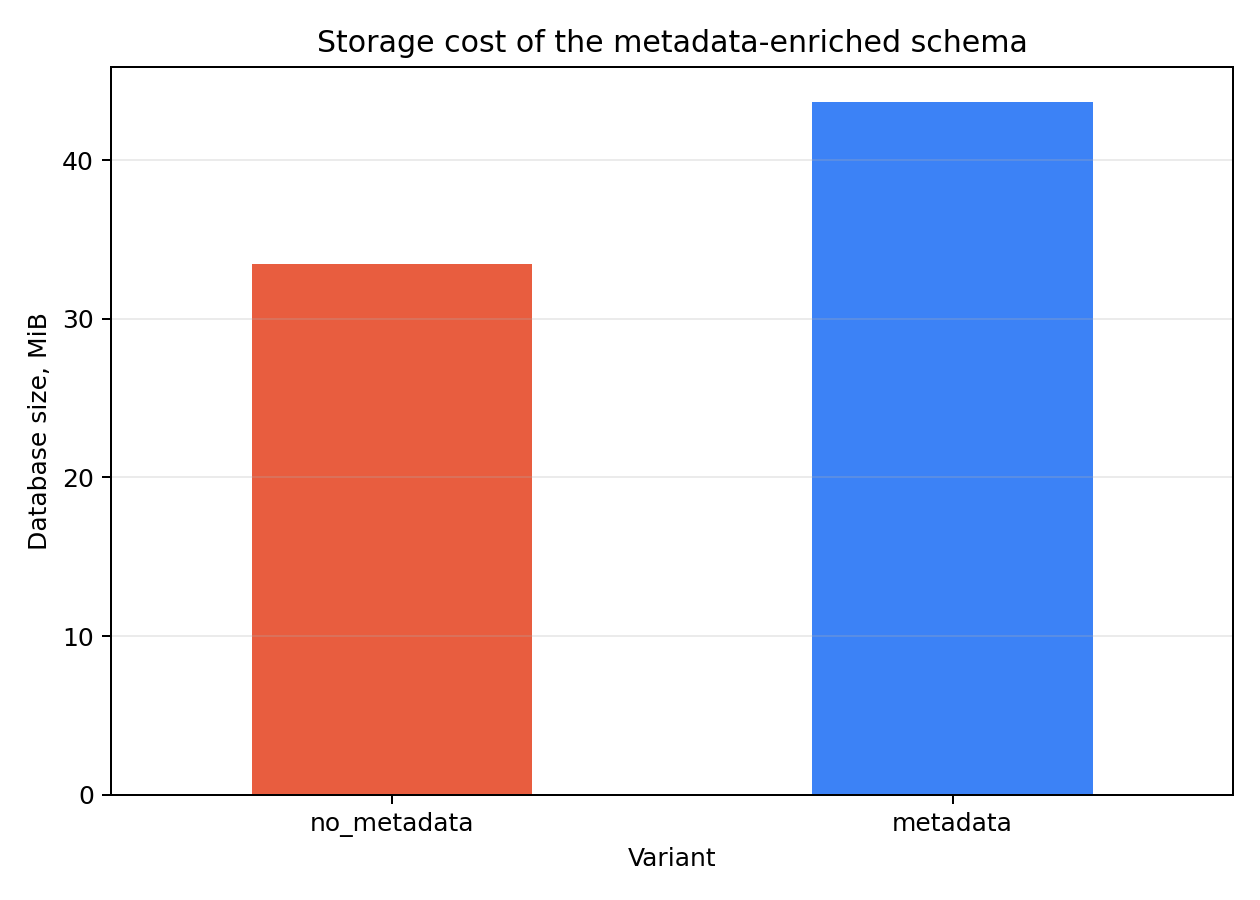

In [6]:
latency_figure, storage_figure = create_figures(ROOT, query_summary, storage)
display(Image(filename=str(latency_figure)))
display(Image(filename=str(storage_figure)))

In [7]:
comparison = query_summary.pivot(index='query', columns='variant', values='median_ms')
comparison['metadata_over_no_metadata'] = comparison['metadata'] / comparison['no_metadata']
display(comparison)

storage_ratio = storage.set_index('variant').loc['metadata', 'database_mib'] / storage.set_index('variant').loc['no_metadata', 'database_mib']
print(f'Metadata-enriched schema storage ratio: {storage_ratio:.3f}x')
print('All shared query results matched:', all(values['metadata'] == values['no_metadata'] for values in result_proof.values()))

variant,metadata,no_metadata,metadata_over_no_metadata
query,,,
accession_filter,1.319452,2.048624,0.644067
average_length,15.014302,14.839275,1.011795
count_all,0.031176,0.029652,1.051396
gc_range_count,4.558031,4.612297,0.988234
indexed_lookup_batch_200,1.629219,1.775414,0.917656
length_range_count,0.661973,0.656077,1.008986
top_100_longest,0.098927,0.139036,0.711521


Metadata-enriched schema storage ratio: 1.304x
All shared query results matched: True


## Valid interpretation

These results quantify metadata overhead and capability on a reproducible local SQLite representation of real Logan contigs. They do not benchmark Logan Search, DIAMOND homology sensitivity, network transfer of the complete Logan release, or AWS Batch performance. The official Logan DIAMOND repository compares `normal` and `target_indexed` modes, which is a separate experiment.